# Project Overview

This notebook extracts simple, interpretable behavioral features from a short video of two octopi.

Each octopus is analyzed separately using a manually defined region of interest (ROI): one ROI for the left side of the frame and one ROI for the right side. The extracted signals focus on frame-to-frame motion magnitude and approximate posture or spread changes inferred from motion-based bounding areas.

## Imports

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load Video and Metadata

In [39]:
# Configuration for this entry task.
VIDEO_PATH = "octopus.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(
        f"Could not open video at {VIDEO_PATH!r}. Check that the file exists and OpenCV can decode it."
    )

fps = cap.get(cv2.CAP_PROP_FPS)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
reported_frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

if fps <= 0:
    cap.release()
    raise RuntimeError("OpenCV reported a non-positive FPS value, so duration cannot be computed reliably.")

# Some compressed videos report an unreliable frame count through OpenCV metadata,
# so count decodable frames directly for a reproducible duration estimate.
total_frames = 0
while True:
    ok, _ = cap.read()
    if not ok:
        break
    total_frames += 1
cap.release()

if total_frames == 0:
    raise RuntimeError(f"Video at {VIDEO_PATH!r} opened but no frames could be decoded.")

duration_seconds = total_frames / fps
REPRESENTATIVE_FRAME_IDX = total_frames // 2

print(f"FPS: {fps:.3f}")
print(f"Frame width: {frame_width}")
print(f"Frame height: {frame_height}")
print(f"Total frame count: {total_frames}")
print(f"Duration (seconds): {duration_seconds:.3f}")
if reported_frame_count and reported_frame_count != total_frames:
    print(
        f"Note: OpenCV metadata reported {reported_frame_count} frames, but {total_frames} frames were actually decoded."
    )

FPS: 59.971
Frame width: 1920
Frame height: 1080
Total frame count: 1801
Duration (seconds): 30.031
Note: OpenCV metadata reported 2104 frames, but 1801 frames were actually decoded.


## Display Representative Frame

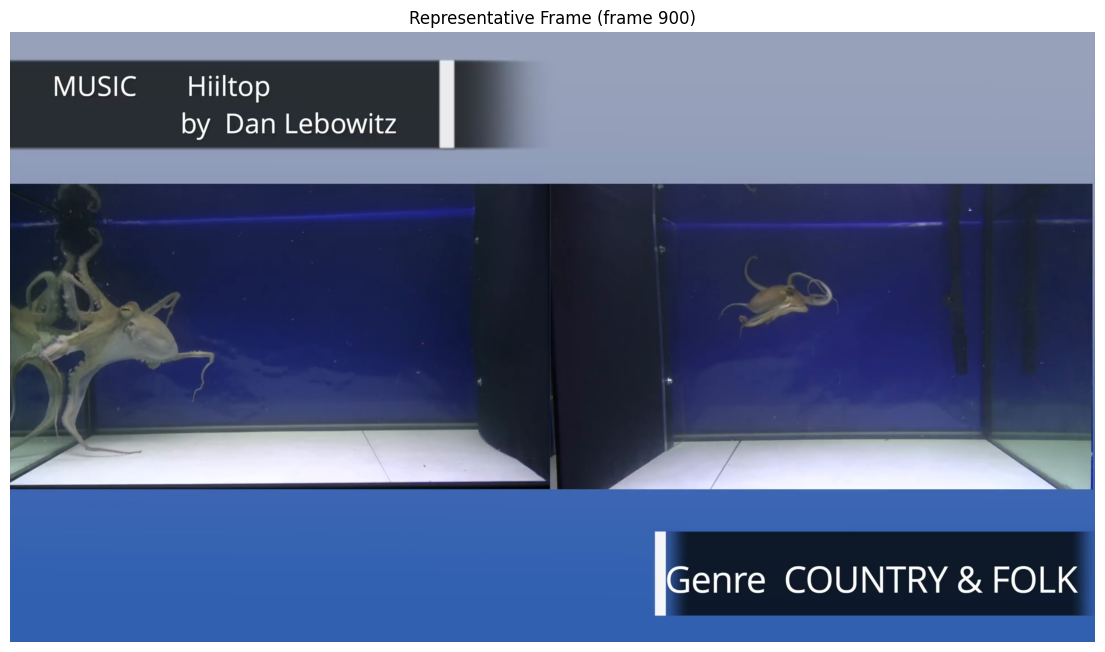

In [40]:
def read_frame_rgb(video_path, frame_index):
    """Load one frame and return it in RGB order for matplotlib."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video at {video_path!r}.")

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ok, frame_bgr = cap.read()
    cap.release()

    if not ok or frame_bgr is None:
        raise RuntimeError(f"Could not read frame {frame_index} from {video_path!r}.")

    return cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)


representative_frame_rgb = read_frame_rgb(VIDEO_PATH, REPRESENTATIVE_FRAME_IDX)

plt.figure(figsize=(14, 8))
plt.imshow(representative_frame_rgb)
plt.title(f"Representative Frame (frame {REPRESENTATIVE_FRAME_IDX})")
plt.axis("off")
plt.show()

## Define ROIs

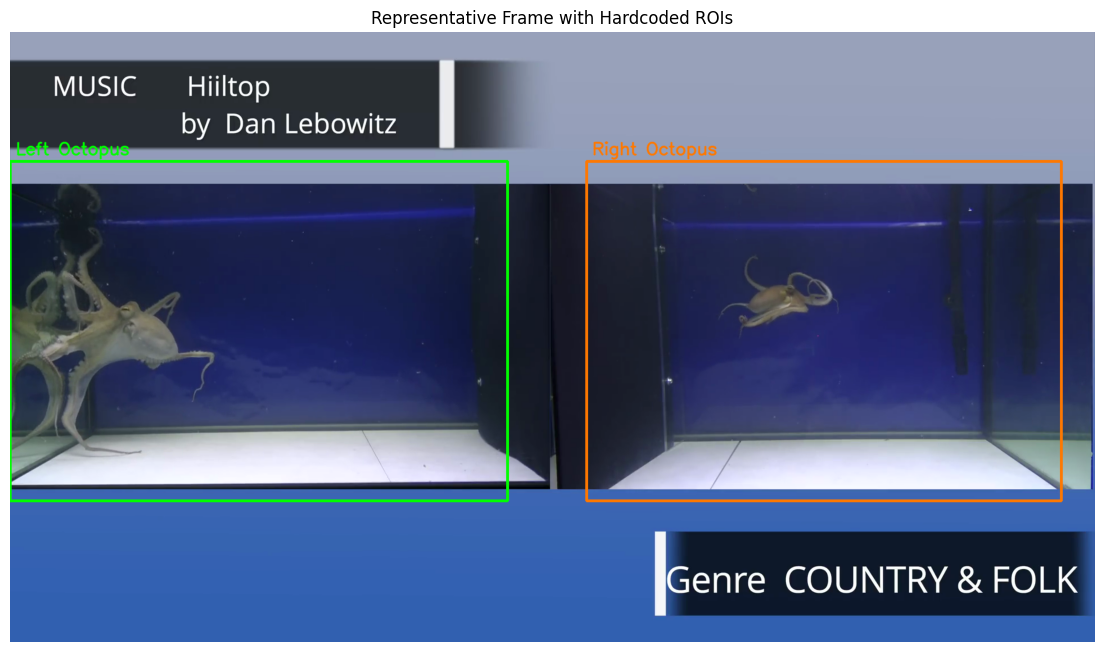

In [41]:
# Format: (x, y, width, height)
LEFT_ROI = (0, 230, 880, 600)
RIGHT_ROI = (1020, 230, 840, 600)
DIFF_THRESHOLD = 25
DIAGNOSTIC_FRAME_IDX = REPRESENTATIVE_FRAME_IDX


def validate_roi(roi, width, height, name):
    x, y, w, h = roi
    if x < 0 or y < 0 or w <= 0 or h <= 0:
        raise ValueError(f"{name} must have non-negative coordinates and positive size. Got {roi}.")
    if x + w > width or y + h > height:
        raise ValueError(
            f"{name} extends beyond the frame bounds. Frame is {width}x{height}, ROI is {roi}."
        )


def crop_roi(frame, roi):
    x, y, w, h = roi
    return frame[y:y + h, x:x + w]


def draw_roi_boxes(frame_rgb, roi_specs):
    annotated = frame_rgb.copy()
    for roi, label, color in roi_specs:
        x, y, w, h = roi
        cv2.rectangle(annotated, (x, y), (x + w, y + h), color, 4)
        text_y = y - 12 if y > 40 else y + 30
        cv2.putText(
            annotated,
            label,
            (x + 10, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            color,
            2,
            cv2.LINE_AA,
        )
    return annotated


validate_roi(LEFT_ROI, frame_width, frame_height, "LEFT_ROI")
validate_roi(RIGHT_ROI, frame_width, frame_height, "RIGHT_ROI")

roi_specs = [
    (LEFT_ROI, "Left Octopus", (0, 255, 0)),
    (RIGHT_ROI, "Right Octopus", (255, 120, 0)),
]

representative_with_rois = draw_roi_boxes(representative_frame_rgb, roi_specs)

plt.figure(figsize=(14, 8))
plt.imshow(representative_with_rois)
plt.title("Representative Frame with Hardcoded ROIs")
plt.axis("off")
plt.show()

## Compute Motion Magnitude

In [42]:
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Could not reopen video at {VIDEO_PATH!r} for motion extraction.")

left_motion = []
right_motion = []
prev_left_gray = None
prev_right_gray = None

while True:
    ok, frame_bgr = cap.read()
    if not ok:
        break

    # Convert the full frame once, then crop grayscale ROIs for both octopi.
    frame_gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    left_gray = crop_roi(frame_gray, LEFT_ROI)
    right_gray = crop_roi(frame_gray, RIGHT_ROI)

    if prev_left_gray is not None:
        left_diff = cv2.absdiff(left_gray, prev_left_gray)
        right_diff = cv2.absdiff(right_gray, prev_right_gray)

        left_motion.append(float(left_diff.mean()))
        right_motion.append(float(right_diff.mean()))

    prev_left_gray = left_gray
    prev_right_gray = right_gray

cap.release()

left_motion = np.array(left_motion, dtype=np.float32)
right_motion = np.array(right_motion, dtype=np.float32)

if len(left_motion) != len(right_motion):
    raise RuntimeError("Left and right motion arrays should have the same length.")

print(f"Computed {len(left_motion)} motion values per octopus.")

Computed 1800 motion values per octopus.


## Compute Contour or Bounding Area Variation

In [43]:
def largest_bounding_box_area(diff_image, threshold_value):
    """Threshold motion and return the largest contour bounding-box area."""
    _, binary = cv2.threshold(diff_image, threshold_value, 255, cv2.THRESH_BINARY)
    contours_info = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = contours_info[0] if len(contours_info) == 2 else contours_info[1]

    max_area = 0.0
    for contour in contours:
        _, _, w, h = cv2.boundingRect(contour)
        max_area = max(max_area, float(w * h))
    return max_area


cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Could not reopen video at {VIDEO_PATH!r} for contour-area extraction.")

left_area = []
right_area = []
prev_left_gray = None
prev_right_gray = None

while True:
    ok, frame_bgr = cap.read()
    if not ok:
        break

    frame_gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    left_gray = crop_roi(frame_gray, LEFT_ROI)
    right_gray = crop_roi(frame_gray, RIGHT_ROI)

    if prev_left_gray is not None:
        left_diff = cv2.absdiff(left_gray, prev_left_gray)
        right_diff = cv2.absdiff(right_gray, prev_right_gray)

        left_area.append(largest_bounding_box_area(left_diff, DIFF_THRESHOLD))
        right_area.append(largest_bounding_box_area(right_diff, DIFF_THRESHOLD))

    prev_left_gray = left_gray
    prev_right_gray = right_gray

cap.release()

left_area = np.array(left_area, dtype=np.float32)
right_area = np.array(right_area, dtype=np.float32)

if len(left_area) != len(right_area):
    raise RuntimeError("Left and right area arrays should have the same length.")

print(f"Computed {len(left_area)} bounding-area values per octopus.")

Computed 1800 bounding-area values per octopus.


## Visualization

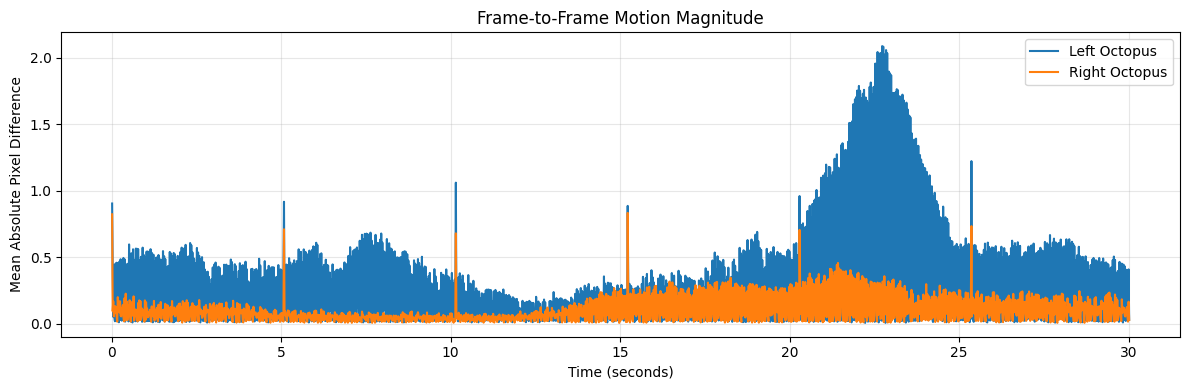

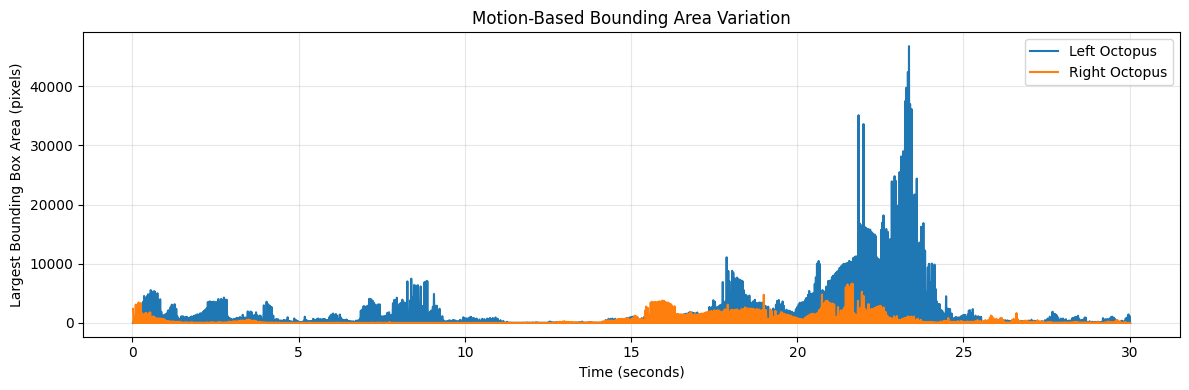

In [44]:
if len(left_motion) != len(left_area):
    raise RuntimeError("Motion and area features should be aligned frame by frame.")

# Each feature value describes change from one frame to the next, so the time axis starts at 1 / fps.
time_seconds = np.arange(1, len(left_motion) + 1) / fps

plt.figure(figsize=(12, 4))
plt.plot(time_seconds, left_motion, label="Left Octopus", linewidth=1.5)
plt.plot(time_seconds, right_motion, label="Right Octopus", linewidth=1.5)
plt.title("Frame-to-Frame Motion Magnitude")
plt.xlabel("Time (seconds)")
plt.ylabel("Mean Absolute Pixel Difference")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(time_seconds, left_area, label="Left Octopus", linewidth=1.5)
plt.plot(time_seconds, right_area, label="Right Octopus", linewidth=1.5)
plt.title("Motion-Based Bounding Area Variation")
plt.xlabel("Time (seconds)")
plt.ylabel("Largest Bounding Box Area (pixels)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

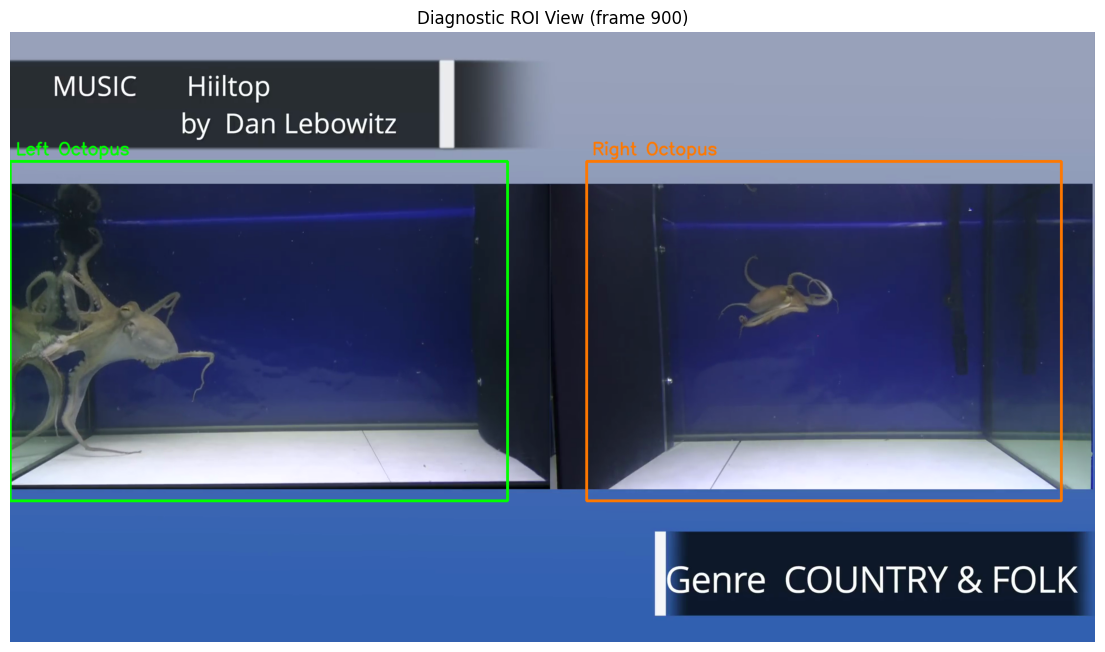

In [45]:
# Simple diagnostic visualization for quick ROI sanity checks.
diagnostic_frame_rgb = read_frame_rgb(VIDEO_PATH, DIAGNOSTIC_FRAME_IDX)
diagnostic_with_rois = draw_roi_boxes(diagnostic_frame_rgb, roi_specs)

plt.figure(figsize=(14, 8))
plt.imshow(diagnostic_with_rois)
plt.title(f"Diagnostic ROI View (frame {DIAGNOSTIC_FRAME_IDX})")
plt.axis("off")
plt.show()

## Notes and Limitations

- These features are interpretable but still approximate summaries of behavior.
- Motion-based contour extraction can be sensitive to threshold choice, small lighting fluctuations, and image noise.
- Posture changes may be partially captured through bounding-area variation, but that signal is only a coarse proxy for shape.
- Richer behavioral inference would benefit from additional modalities or more accurate segmentation.

## Short Analysis

The two selected features capture complementary aspects of visible behavior in a simple and interpretable way. Frame-to-frame motion magnitude reflects how much each octopus is moving inside its ROI, so it is useful for detecting bursts of activity, locomotion, and large arm motions. Bounding-area variation provides a coarse proxy for posture change, because the moving region typically expands when the body spreads out or the arms extend and contracts when the animal becomes more compact. Together, these signals can separate relatively still periods from active bouts and can reveal differences between the left and right octopus over time. The main limitation is that both features are approximate and depend on motion differencing, so they are sensitive to threshold choice, reflections, compression artifacts, and any background change that produces pixel motion. They also do not identify specific behaviors directly, because different actions can produce similar motion and area traces. Additional posture-aware measurements such as body centroid, arm extension, or shape descriptors would make the inference more behaviorally specific, while audio could help align movement bursts with external events or disturbances that are not visible in the frame.

## Create Summary Video

This optional section renders a side-by-side summary video. The source video appears on the left, while the right side shows the motion and bounding-area signals over time. Each octopus is labeled as `HIGH ACTIVITY` or `LOW ACTIVITY` using a smoothed motion signal with hysteresis, so the labels do not flicker on and off from one frame to the next.

In [ ]:
SUMMARY_VIDEO_PATH = "octopus_activity_summary.mp4"
ACTIVITY_ENTER_PERCENTILE = 80.0
ACTIVITY_EXIT_PERCENTILE = 65.0
ACTIVITY_SMOOTHING_SECONDS = 0.50
ACTIVITY_HOLD_SECONDS = 0.75
GRAPH_PANEL_WIDTH = 960

LEFT_COLOR = (60, 190, 80)
RIGHT_COLOR = (0, 150, 255)
HIGH_ACTIVITY_COLOR = (30, 45, 220)
LOW_ACTIVITY_COLOR = (50, 150, 50)
TEXT_COLOR = (25, 25, 25)
GRID_COLOR = (225, 225, 225)
PLOT_BG_COLOR = (255, 255, 255)
PANEL_BG_COLOR = (245, 246, 248)


def smooth_signal(series, window_size):
    if window_size <= 1:
        return series.astype(np.float32).copy()

    kernel = np.ones(window_size, dtype=np.float32) / window_size
    pad_left = window_size // 2
    pad_right = window_size - 1 - pad_left
    padded = np.pad(series.astype(np.float32), (pad_left, pad_right), mode="edge")
    return np.convolve(padded, kernel, mode="valid").astype(np.float32)


def compute_activity_states(signal, enter_percentile, exit_percentile, hold_frames):
    enter_threshold = float(np.percentile(signal, enter_percentile))
    exit_threshold = float(np.percentile(signal, exit_percentile))
    if exit_threshold >= enter_threshold:
        exit_threshold = 0.85 * enter_threshold

    states = np.zeros(len(signal), dtype=bool)
    is_high = False
    remaining_hold = 0

    for idx, value in enumerate(signal):
        if is_high:
            if value >= exit_threshold:
                remaining_hold = hold_frames
            elif remaining_hold > 0:
                remaining_hold -= 1
            else:
                is_high = False
        else:
            if value >= enter_threshold:
                is_high = True
                remaining_hold = hold_frames

        states[idx] = is_high

    return states, enter_threshold, exit_threshold


activity_window_frames = max(3, int(round(ACTIVITY_SMOOTHING_SECONDS * fps)))
activity_hold_frames = max(1, int(round(ACTIVITY_HOLD_SECONDS * fps)))

left_activity_signal = smooth_signal(left_motion, activity_window_frames)
right_activity_signal = smooth_signal(right_motion, activity_window_frames)

left_activity_state, left_enter_threshold, left_exit_threshold = compute_activity_states(
    left_activity_signal,
    ACTIVITY_ENTER_PERCENTILE,
    ACTIVITY_EXIT_PERCENTILE,
    activity_hold_frames,
)
right_activity_state, right_enter_threshold, right_exit_threshold = compute_activity_states(
    right_activity_signal,
    ACTIVITY_ENTER_PERCENTILE,
    ACTIVITY_EXIT_PERCENTILE,
    activity_hold_frames,
)


def draw_status_box(frame, x, y, title, subtitle, status_color):
    line1_size, _ = cv2.getTextSize(title, cv2.FONT_HERSHEY_SIMPLEX, 0.9, 2)
    line2_size, _ = cv2.getTextSize(subtitle, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)

    box_width = max(line1_size[0], line2_size[0]) + 24
    box_height = line1_size[1] + line2_size[1] + 34

    x1 = max(15, x)
    y1 = max(15, y)
    x2 = min(frame.shape[1] - 15, x1 + box_width)
    y2 = min(frame.shape[0] - 15, y1 + box_height)
    x1 = x2 - box_width
    y1 = y2 - box_height

    overlay = frame.copy()
    cv2.rectangle(overlay, (x1, y1), (x2, y2), (252, 252, 252), -1)
    cv2.addWeighted(overlay, 0.78, frame, 0.22, 0, frame)
    cv2.rectangle(frame, (x1, y1), (x2, y2), status_color, 2)

    cv2.putText(
        frame,
        title,
        (x1 + 12, y1 + 24),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        status_color,
        2,
        cv2.LINE_AA,
    )
    cv2.putText(
        frame,
        subtitle,
        (x1 + 12, y2 - 12),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        TEXT_COLOR,
        2,
        cv2.LINE_AA,
    )


def annotate_summary_frame(frame_bgr, feature_index):
    annotated = frame_bgr.copy()

    cv2.rectangle(
        annotated,
        (LEFT_ROI[0], LEFT_ROI[1]),
        (LEFT_ROI[0] + LEFT_ROI[2], LEFT_ROI[1] + LEFT_ROI[3]),
        LEFT_COLOR,
        3,
    )
    cv2.rectangle(
        annotated,
        (RIGHT_ROI[0], RIGHT_ROI[1]),
        (RIGHT_ROI[0] + RIGHT_ROI[2], RIGHT_ROI[1] + RIGHT_ROI[3]),
        RIGHT_COLOR,
        3,
    )

    left_signal_value = float(left_activity_signal[feature_index])
    right_signal_value = float(right_activity_signal[feature_index])

    left_is_high = bool(left_activity_state[feature_index])
    right_is_high = bool(right_activity_state[feature_index])

    left_status = "HIGH ACTIVITY" if left_is_high else "LOW ACTIVITY"
    right_status = "HIGH ACTIVITY" if right_is_high else "LOW ACTIVITY"
    left_status_color = HIGH_ACTIVITY_COLOR if left_is_high else LOW_ACTIVITY_COLOR
    right_status_color = HIGH_ACTIVITY_COLOR if right_is_high else LOW_ACTIVITY_COLOR

    draw_status_box(
        annotated,
        LEFT_ROI[0] + 15,
        LEFT_ROI[1] + 10,
        f"Left Octopus: {left_status}",
        f"signal {left_signal_value:.3f}",
        left_status_color,
    )
    draw_status_box(
        annotated,
        RIGHT_ROI[0] + 15,
        RIGHT_ROI[1] + 10,
        f"Right Octopus: {right_status}",
        f"signal {right_signal_value:.3f}",
        right_status_color,
    )

    return annotated


def scale_series_to_plot(series, rect, y_max):
    x0, y0, width, height = rect
    if len(series) == 1:
        xs = np.array([x0 + width // 2], dtype=np.int32)
    else:
        xs = x0 + np.round(np.linspace(0, width - 1, len(series))).astype(np.int32)

    denom = max(y_max, 1e-6)
    normalized = np.clip(series / denom, 0.0, 1.0)
    ys = y0 + height - 1 - np.round(normalized * (height - 1)).astype(np.int32)
    return np.stack([xs, ys], axis=1).reshape(-1, 1, 2)


def draw_plot_frame(panel, rect, title, ylabel, duration_seconds, y_max):
    x0, y0, width, height = rect

    cv2.putText(panel, title, (x0, y0 - 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, TEXT_COLOR, 2, cv2.LINE_AA)
    cv2.putText(panel, ylabel, (x0, y0 - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.52, (90, 90, 90), 1, cv2.LINE_AA)
    cv2.rectangle(panel, (x0, y0), (x0 + width, y0 + height), PLOT_BG_COLOR, -1)
    cv2.rectangle(panel, (x0, y0), (x0 + width, y0 + height), (180, 180, 180), 1)

    for frac in np.linspace(0.2, 0.8, 4):
        x = x0 + int(round(frac * width))
        cv2.line(panel, (x, y0), (x, y0 + height), GRID_COLOR, 1)
    for frac in np.linspace(0.25, 0.75, 3):
        y = y0 + int(round(frac * height))
        cv2.line(panel, (x0, y), (x0 + width, y), GRID_COLOR, 1)

    tick_specs = [
        (0.0, "0.0s"),
        (duration_seconds / 2.0, f"{duration_seconds / 2.0:.1f}s"),
        (duration_seconds, f"{duration_seconds:.1f}s"),
    ]
    for tick_value, tick_label in tick_specs:
        x = x0 + int(round((tick_value / max(duration_seconds, 1e-6)) * width))
        x = min(x0 + width, max(x0, x))
        text_size, _ = cv2.getTextSize(tick_label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        label_x = int(np.clip(x - text_size[0] // 2, x0, x0 + width - text_size[0]))
        cv2.line(panel, (x, y0 + height), (x, y0 + height + 6), (120, 120, 120), 1)
        cv2.putText(
            panel,
            tick_label,
            (label_x, y0 + height + 24),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (90, 90, 90),
            1,
            cv2.LINE_AA,
        )

    cv2.putText(panel, f"{y_max:.2f}", (x0 - 58, y0 + 8), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (90, 90, 90), 1, cv2.LINE_AA)
    cv2.putText(panel, "0.00", (x0 - 58, y0 + height + 4), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (90, 90, 90), 1, cv2.LINE_AA)


def draw_legend(panel, x, y):
    cv2.line(panel, (x, y), (x + 28, y), LEFT_COLOR, 3)
    cv2.putText(panel, "Left", (x + 38, y + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, TEXT_COLOR, 1, cv2.LINE_AA)
    cv2.line(panel, (x + 120, y), (x + 148, y), RIGHT_COLOR, 3)
    cv2.putText(panel, "Right", (x + 158, y + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, TEXT_COLOR, 1, cv2.LINE_AA)


def build_summary_panel_base():
    panel = np.full((frame_height, GRAPH_PANEL_WIDTH, 3), PANEL_BG_COLOR, dtype=np.uint8)

    cv2.putText(
        panel,
        "Octopus Activity Summary",
        (40, 52),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.1,
        TEXT_COLOR,
        2,
        cv2.LINE_AA,
    )
    cv2.putText(
        panel,
        "Labels use smoothed motion with hysteresis to avoid flicker.",
        (40, 84),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.62,
        (90, 90, 90),
        1,
        cv2.LINE_AA,
    )
    cv2.putText(
        panel,
        f"Enter {ACTIVITY_ENTER_PERCENTILE:.0f}th pct | Exit {ACTIVITY_EXIT_PERCENTILE:.0f}th pct | Hold {ACTIVITY_HOLD_SECONDS:.2f}s",
        (40, 110),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.58,
        (90, 90, 90),
        1,
        cv2.LINE_AA,
    )
    draw_legend(panel, 40, 138)

    motion_rect = (80, 205, GRAPH_PANEL_WIDTH - 150, 230)
    info_rect = (80, 470, GRAPH_PANEL_WIDTH - 150, 100)
    area_rect = (80, 710, GRAPH_PANEL_WIDTH - 150, 210)

    motion_y_max = float(max(left_activity_signal.max(), right_activity_signal.max()) * 1.08)
    area_y_max = float(max(left_area.max(), right_area.max()) * 1.08)
    duration_seconds_for_plot = float(time_seconds[-1])

    draw_plot_frame(panel, motion_rect, "Smoothed Motion Signal", "used for HIGH / LOW labels", duration_seconds_for_plot, motion_y_max)
    draw_plot_frame(panel, area_rect, "Bounding Area Variation", "largest bbox area", duration_seconds_for_plot, area_y_max)

    activity_left_points = scale_series_to_plot(left_activity_signal, motion_rect, motion_y_max)
    activity_right_points = scale_series_to_plot(right_activity_signal, motion_rect, motion_y_max)
    area_left_points = scale_series_to_plot(left_area, area_rect, area_y_max)
    area_right_points = scale_series_to_plot(right_area, area_rect, area_y_max)

    cv2.polylines(panel, [activity_left_points], False, LEFT_COLOR, 2, cv2.LINE_AA)
    cv2.polylines(panel, [activity_right_points], False, RIGHT_COLOR, 2, cv2.LINE_AA)
    cv2.polylines(panel, [area_left_points], False, LEFT_COLOR, 2, cv2.LINE_AA)
    cv2.polylines(panel, [area_right_points], False, RIGHT_COLOR, 2, cv2.LINE_AA)

    left_threshold_y = scale_series_to_plot(np.array([left_enter_threshold], dtype=np.float32), motion_rect, motion_y_max)[0, 0, 1]
    right_threshold_y = scale_series_to_plot(np.array([right_enter_threshold], dtype=np.float32), motion_rect, motion_y_max)[0, 0, 1]
    cv2.line(panel, (motion_rect[0], left_threshold_y), (motion_rect[0] + motion_rect[2], left_threshold_y), LEFT_COLOR, 1)
    cv2.line(panel, (motion_rect[0], right_threshold_y), (motion_rect[0] + motion_rect[2], right_threshold_y), RIGHT_COLOR, 1)

    return {
        "panel": panel,
        "motion_rect": motion_rect,
        "info_rect": info_rect,
        "area_rect": area_rect,
        "activity_left_points": activity_left_points,
        "activity_right_points": activity_right_points,
        "area_left_points": area_left_points,
        "area_right_points": area_right_points,
    }


def add_dynamic_graph_overlay(panel_base, plot_state, feature_index):
    panel = panel_base.copy()

    motion_cursor_x = int(plot_state["activity_left_points"][feature_index, 0, 0])
    area_cursor_x = int(plot_state["area_left_points"][feature_index, 0, 0])
    motion_rect = plot_state["motion_rect"]
    info_rect = plot_state["info_rect"]
    area_rect = plot_state["area_rect"]

    cv2.line(panel, (motion_cursor_x, motion_rect[1]), (motion_cursor_x, motion_rect[1] + motion_rect[3]), (70, 70, 70), 2)
    cv2.line(panel, (area_cursor_x, area_rect[1]), (area_cursor_x, area_rect[1] + area_rect[3]), (70, 70, 70), 2)

    cv2.circle(panel, tuple(plot_state["activity_left_points"][feature_index, 0]), 6, LEFT_COLOR, -1, cv2.LINE_AA)
    cv2.circle(panel, tuple(plot_state["activity_right_points"][feature_index, 0]), 6, RIGHT_COLOR, -1, cv2.LINE_AA)
    cv2.circle(panel, tuple(plot_state["area_left_points"][feature_index, 0]), 6, LEFT_COLOR, -1, cv2.LINE_AA)
    cv2.circle(panel, tuple(plot_state["area_right_points"][feature_index, 0]), 6, RIGHT_COLOR, -1, cv2.LINE_AA)

    ix, iy, iw, ih = info_rect
    overlay = panel.copy()
    cv2.rectangle(overlay, (ix, iy), (ix + iw, iy + ih), (252, 252, 252), -1)
    cv2.addWeighted(overlay, 0.90, panel, 0.10, 0, panel)
    cv2.rectangle(panel, (ix, iy), (ix + iw, iy + ih), (210, 210, 210), 1)

    current_time = float(time_seconds[feature_index])
    left_status = "HIGH" if bool(left_activity_state[feature_index]) else "LOW"
    right_status = "HIGH" if bool(right_activity_state[feature_index]) else "LOW"
    cv2.putText(panel, f"Current time: {current_time:.2f}s", (ix + 16, iy + 24), cv2.FONT_HERSHEY_SIMPLEX, 0.68, TEXT_COLOR, 2, cv2.LINE_AA)
    cv2.putText(
        panel,
        f"Left: {left_status} | signal {left_activity_signal[feature_index]:.3f} | enter {left_enter_threshold:.3f} | exit {left_exit_threshold:.3f}",
        (ix + 16, iy + 54),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.54,
        LEFT_COLOR,
        1,
        cv2.LINE_AA,
    )
    cv2.putText(
        panel,
        f"Right: {right_status} | signal {right_activity_signal[feature_index]:.3f} | enter {right_enter_threshold:.3f} | exit {right_exit_threshold:.3f}",
        (ix + 16, iy + 82),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.54,
        RIGHT_COLOR,
        1,
        cv2.LINE_AA,
    )

    return panel


summary_panel_state = build_summary_panel_base()
print(f"Summary video will be written to: {SUMMARY_VIDEO_PATH}")
print(f"Smoothing window: {activity_window_frames} frames (~{activity_window_frames / fps:.2f}s)")
print(f"Left thresholds (enter/exit): {left_enter_threshold:.3f} / {left_exit_threshold:.3f}")
print(f"Right thresholds (enter/exit): {right_enter_threshold:.3f} / {right_exit_threshold:.3f}")

In [ ]:
summary_writer = cv2.VideoWriter(
    SUMMARY_VIDEO_PATH,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (frame_width + GRAPH_PANEL_WIDTH, frame_height),
)
if not summary_writer.isOpened():
    raise RuntimeError(f"Could not open video writer for {SUMMARY_VIDEO_PATH!r}.")

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    summary_writer.release()
    raise RuntimeError(f"Could not reopen video at {VIDEO_PATH!r} for summary rendering.")

frame_index = 0
max_feature_index = len(left_motion) - 1

while True:
    ok, frame_bgr = cap.read()
    if not ok:
        break

    feature_index = min(max(frame_index - 1, 0), max_feature_index)
    annotated_frame = annotate_summary_frame(frame_bgr, feature_index)
    graph_panel = add_dynamic_graph_overlay(summary_panel_state["panel"], summary_panel_state, feature_index)
    combined_frame = np.concatenate([annotated_frame, graph_panel], axis=1)
    summary_writer.write(combined_frame)

    frame_index += 1

cap.release()
summary_writer.release()

print(f"Rendered {frame_index} frames.")
print(f"Saved summary video to {SUMMARY_VIDEO_PATH}")

from IPython.display import Video, display
display(Video(SUMMARY_VIDEO_PATH, embed=True, mimetype="video/mp4", html_attributes='controls width="1400"'))